# Data-Driven Discovery of Governing Equations with SINDy

This notebook uses **Sparse Identification of Nonlinear Dynamics (SINDy)** to recover the differential equations of three physical systems from time-series data alone. The method is implemented with [PySINDy](https://github.com/dynamicslab/pysindy).

| # | System | What it shows |
|---|---|---|
| 1 | Lorenz attractor | Chaotic dynamics, polynomial library, robustness to measurement noise |
| 2 | Nonlinear pendulum | Non-polynomial physics (`sin θ`) and identifying damping |
| 3 | Michaelis–Menten kinetics | Why the choice of candidate library matters: polynomial vs rational |

Every case follows the same workflow:

1. **Simulate** the true system to generate state data $X(t)$.
2. **Differentiate** numerically to estimate $\dot X$.
3. **Build a library** $\Theta(X)$ of candidate functions (polynomials, trigonometric or rational terms).
4. **Sparse regression**: solve $\dot X \approx \Theta(X)\,\Xi$ with sequentially thresholded least squares (STLSQ). STLSQ sets small coefficients to zero, so the model stays interpretable.
5. **Validate** by simulating the identified model from an initial condition not used in training, then comparing it against the true system.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp
import pysindy as ps
from pysindy.feature_library import PolynomialLibrary, CustomLibrary

np.random.seed(0)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("pysindy", ps.__version__)

pysindy 2.1.0


In [ ]:
def compare_coefficients(model, true_coefs):
    # Print identified vs. true coefficients for every term that is non-zero in either.
    names = model.get_feature_names()
    xi = model.coefficients()
    lhs = model.feature_names
    print(f"{'equation':<10}{'term':<14}{'true':>10}{'identified':>12}{'error %':>10}")
    for i, eq in enumerate(lhs):
        for j, term in enumerate(names):
            t = true_coefs.get((eq, term), 0.0)
            v = xi[i, j]
            if t == 0 and abs(v) < 1e-10:
                continue
            err = abs(v - t) / abs(t) * 100 if t != 0 else float("nan")
            print(f"{eq + chr(39):<10}{term:<14}{t:>10.4f}{v:>12.4f}{err:>10.3f}")


def plot_validation(t, X_true, X_model, labels, title):
    fig, axs = plt.subplots(len(labels), 1, figsize=(10, 2.2 * len(labels)), sharex=True)
    for i, ax in enumerate(np.atleast_1d(axs)):
        ax.plot(t, X_true[:, i], "k-", lw=1.4, label="True system")
        ax.plot(t, X_model[:, i], "r--", lw=1.4, label="SINDy model")
        ax.set_ylabel(labels[i])
    np.atleast_1d(axs)[0].legend(loc="upper right")
    np.atleast_1d(axs)[-1].set_xlabel("Time (s)")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

## 1. Lorenz attractor

$$
\dot x = \sigma (y - x), \qquad
\dot y = x(\rho - z) - y, \qquad
\dot z = xy - \beta z,
\qquad \sigma = 10,\ \rho = 28,\ \beta = 8/3
$$

The system is chaotic, so small errors in the identified coefficients grow exponentially over time. That makes it a demanding test. The candidate library is all polynomials up to degree 2 in $(x, y, z)$: 10 terms per equation, 30 coefficients in total, of which only 7 are truly non-zero.

In [ ]:
sigma, rho, beta = 10.0, 28.0, 8.0 / 3.0

def lorenz(state, t):
    x, y, z = state
    return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

dt = 0.002
t_train = np.arange(0, 10, dt)
X_train = odeint(lorenz, [-8, 8, 27], t_train)

lorenz_model = ps.SINDy(
    feature_library=PolynomialLibrary(degree=2),
    optimizer=ps.STLSQ(threshold=0.1),
)
lorenz_model.fit(X_train, t=dt, feature_names=["x", "y", "z"])
lorenz_model.print()

(x)' = -9.999 x +  9.999 y
(y)' =  27.992 x + -0.999 y + -1.000 x z
(z)' = -2.666 z +  1.000 x y


In [ ]:
lorenz_true = {
    ("x", "x"): -sigma, ("x", "y"): sigma,
    ("y", "x"): rho, ("y", "y"): -1.0, ("y", "x z"): -1.0,
    ("z", "z"): -beta, ("z", "x y"): 1.0,
}
compare_coefficients(lorenz_model, lorenz_true)

equation  term                true  identified   error %
x'        x               -10.0000     -9.9992     0.008
x'        y                10.0000      9.9992     0.008
y'        x                28.0000     27.9922     0.028
y'        y                -1.0000     -0.9985     0.147
y'        x z              -1.0000     -0.9998     0.022
z'        z                -2.6667     -2.6664     0.011
z'        x y               1.0000      0.9999     0.012


**Validation on an unseen initial condition.** The model is simulated from $(8, 7, 15)$, which was not used in training, and compared with the true system over 15 s.

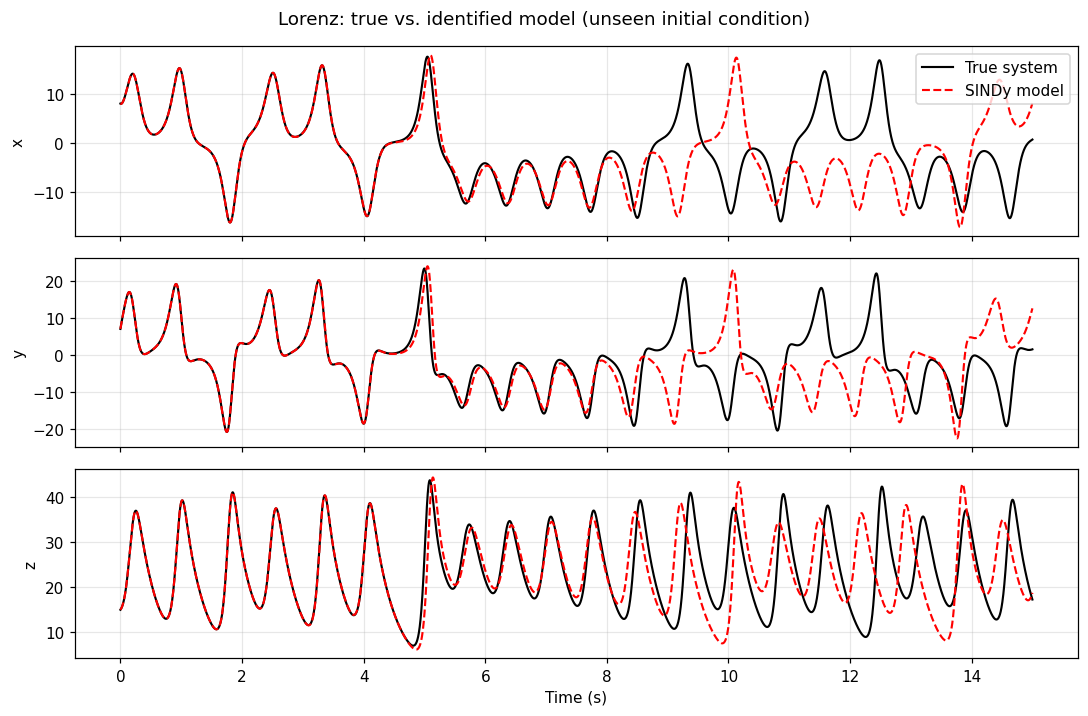

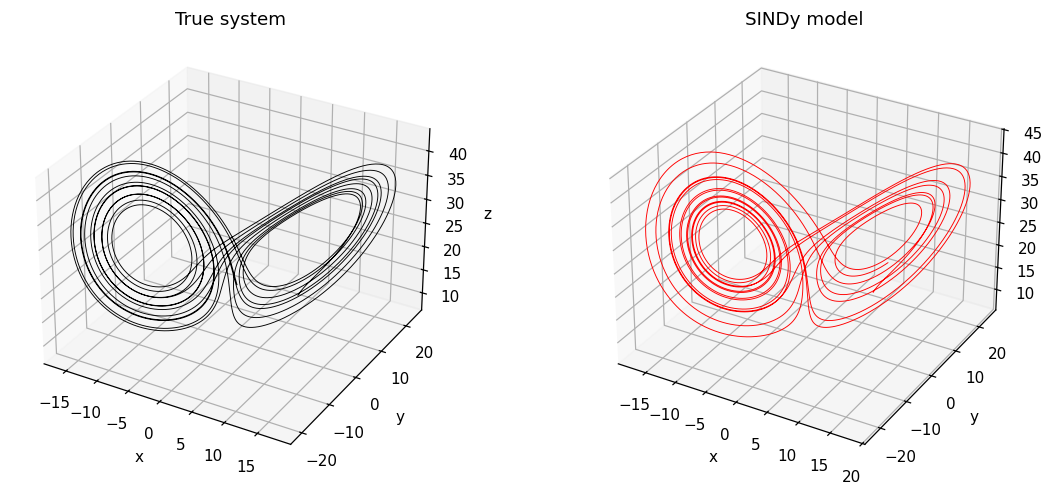

In [ ]:
t_test = np.arange(0, 15, dt)
x0_test = [8, 7, 15]
X_test = odeint(lorenz, x0_test, t_test)
X_sim = lorenz_model.simulate(x0_test, t_test)

plot_validation(t_test, X_test, X_sim, ["x", "y", "z"], "Lorenz: true vs. identified model (unseen initial condition)")

fig = plt.figure(figsize=(11, 4.5))
for k, (data, name, c) in enumerate([(X_test, "True system", "k"), (X_sim, "SINDy model", "r")]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    ax.plot(*data.T, color=c, lw=0.6)
    ax.set_title(name); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
fig.tight_layout()
plt.show()

The trajectories match for about 5 s, roughly 5 Lyapunov times (the Lyapunov time of the Lorenz system is about 1.1 s). After that, chaos amplifies the tiny coefficient errors and the trajectories separate. This divergence is unavoidable for any model of a chaotic system that is not exact. The 3-D plots show that the identified model reproduces the geometry of the butterfly attractor.

### 1b. Robustness to measurement noise

Real measurements are noisy, and differentiating noisy data amplifies the noise. Here Gaussian noise of 1 % of each state's standard deviation is added to the training data. The table compares plain finite differences with smoothed finite differences (a Savitzky–Golay filter followed by differentiation).

In [ ]:
noise = 0.01 * X_train.std(axis=0) * np.random.randn(*X_train.shape)
X_noisy = X_train + noise

def max_rel_error(model):
    xi = model.coefficients()
    names = model.get_feature_names()
    errs = [abs(xi[["x", "y", "z"].index(eq), names.index(term)] - v) / abs(v)
            for (eq, term), v in lorenz_true.items()]
    n_terms = int(np.count_nonzero(xi))
    return 100 * max(errs), n_terms

for label, diff in [("Finite differences", ps.FiniteDifference()),
                    ("Smoothed finite differences", ps.SmoothedFiniteDifference())]:
    m = ps.SINDy(feature_library=PolynomialLibrary(degree=2),
                 optimizer=ps.STLSQ(threshold=0.1),
                 differentiation_method=diff)
    m.fit(X_noisy, t=dt, feature_names=["x", "y", "z"])
    err, n = max_rel_error(m)
    print(f"{label:<30} active terms: {n:>2} (true: 7)   max coefficient error: {err:6.2f} %")

Finite differences             active terms:  7 (true: 7)   max coefficient error:   4.59 %
Smoothed finite differences    active terms:  7 (true: 7)   max coefficient error:   1.26 %


## 2. Nonlinear pendulum

$$
\ddot\theta = -\frac{c}{m}\,\dot\theta - \frac{g}{l}\,\sin\theta,
\qquad g/l = 9.8/0.15 \approx 65.33\ \mathrm{s^{-2}}
$$

It is written as a first-order system with $x_1 = \theta$ and $x_2 = \dot\theta$. A purely polynomial library could only approximate $\sin\theta$ by a truncated Taylor series. Adding $\sin$ and $\cos$ to the library lets SINDy find the exact nonlinearity, which also holds for large swings.

The pendulum is identified both **undamped** and **damped** ($c/m = 0.75\ \mathrm{s^{-1}}$).

In [ ]:
g, l = 9.8, 0.15
m_p, c_p = 2.0, 1.5

def pendulum(c):
    def rhs(state, t):
        theta, omega = state
        return [omega, -(c / m_p) * omega - (g / l) * np.sin(theta)]
    return rhs

pend_lib = PolynomialLibrary(degree=1) + CustomLibrary(
    library_functions=[lambda s: np.sin(s), lambda s: np.cos(s)],
    function_names=[lambda s: f"sin({s})", lambda s: f"cos({s})"],
)

dt_p = 0.002
t_p = np.arange(0, 10, dt_p)
pend_models = {}
for name, c in [("Undamped", 0.0), ("Damped", c_p)]:
    X = odeint(pendulum(c), [0.5, 0.0], t_p)
    model = ps.SINDy(feature_library=pend_lib, optimizer=ps.STLSQ(threshold=0.05))
    model.fit(X, t=dt_p, feature_names=["x1", "x2"])
    pend_models[name] = (model, c)
    damping = f"-{c / m_p:.3f} x2 " if c else ""
    print(f"--- {name} (true: x2' = {damping}-{g / l:.3f} sin(x1)) ---")
    model.print()

--- Undamped (true: x2' = -65.333 sin(x1)) ---
(x1)' =  1.000 x2
(x2)' = -0.024 x1 + -65.305 sin(x1)
--- Damped (true: x2' = -0.750 x2 -65.333 sin(x1)) ---
(x1)' =  1.000 x2
(x2)' = -0.013 x1 + -0.750 x2 + -65.317 sin(x1)


Both models recover $g/l$ to within 0.05 %, and the damped model finds $c/m = 0.750$. The small extra $x_1$ term (about 0.02, against 65 for the $\sin$ term) absorbs numerical-differentiation error and has a negligible effect.

**Validation at large amplitude.** Training used $\theta_0 = 0.5$ rad. Testing uses $\theta_0 = \pi/2$ (90°), well outside the small-angle regime where $\sin\theta \approx \theta$.

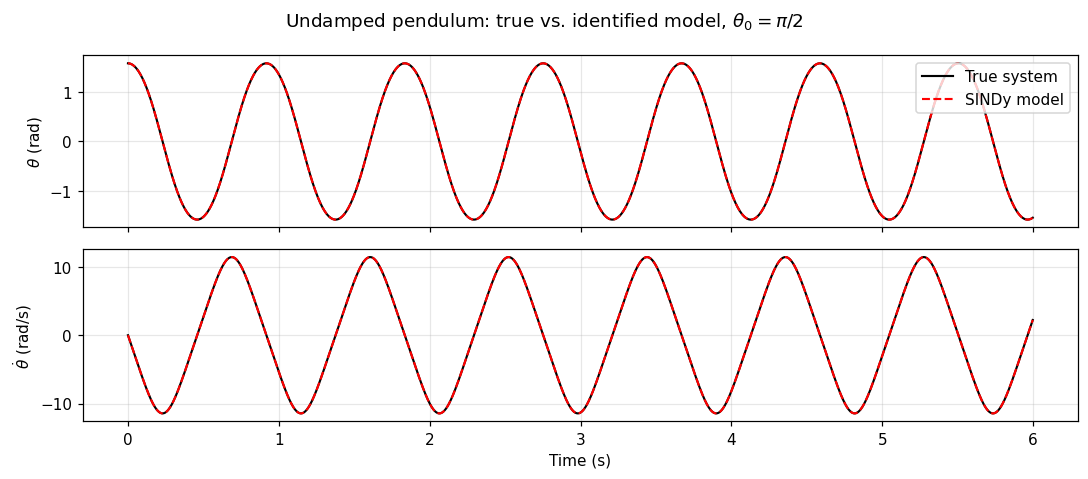

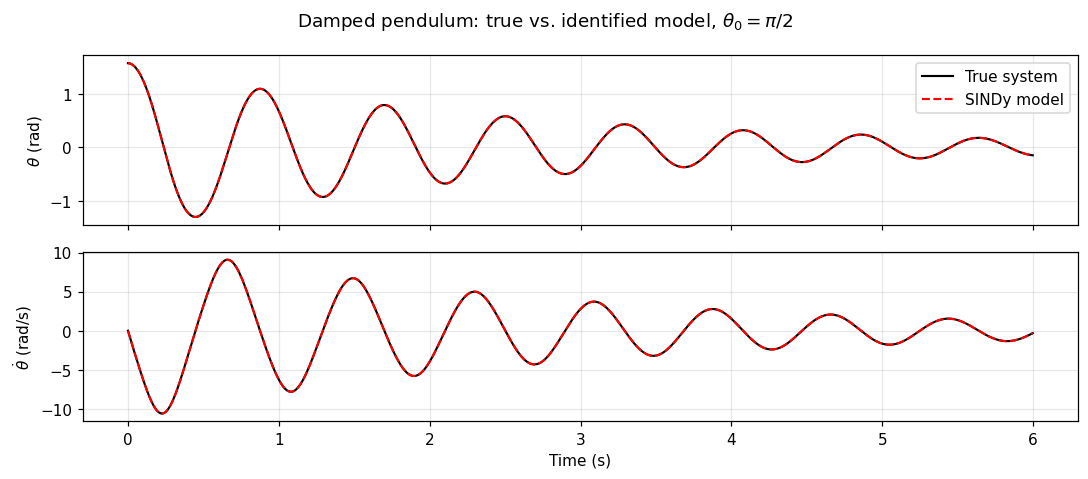

In [ ]:
t_pt = np.arange(0, 6, dt_p)
x0_p = [np.pi / 2, 0.0]
for name, (model, c) in pend_models.items():
    X_true = odeint(pendulum(c), x0_p, t_pt)
    X_sim = model.simulate(x0_p, t_pt)
    plot_validation(t_pt, X_true, X_sim, [r"$\theta$ (rad)", r"$\dot\theta$ (rad/s)"],
                    f"{name} pendulum: true vs. identified model, $\\theta_0 = \\pi/2$")

## 3. Michaelis–Menten kinetics: choosing the library

$$
\dot x = -\frac{V_{\max}\,x}{K_m + x}, \qquad V_{\max} = 1.5,\ K_m = 0.8
$$

The right-hand side is **rational**, so no finite polynomial expresses it exactly. This section shows what happens when the library does not contain the right kind of function.

In [ ]:
V_max, K_m = 1.5, 0.8

def michaelis_menten(t, x):
    return [-V_max * x[0] / (K_m + x[0])]

t_mm = np.linspace(0, 10, 1000)
dt_mm = t_mm[1] - t_mm[0]
x_mm = solve_ivp(michaelis_menten, (0, 10), [2.0], t_eval=t_mm, rtol=1e-10, atol=1e-12).y.T

# (a) Polynomial library
poly_model = ps.SINDy(feature_library=PolynomialLibrary(degree=3),
                      optimizer=ps.STLSQ(threshold=0.05))
poly_model.fit(x_mm, t=dt_mm, feature_names=["x"])
print("(a) Polynomial library, degree 3:")
poly_model.print()

# (b) Library with rational candidate terms
rational_lib = CustomLibrary(
    library_functions=[lambda x: x, lambda x: x**2,
                       lambda x: x / (0.8 + x), lambda x: 1 / (1.0 + x)],
    function_names=[lambda s: f"{s}", lambda s: f"{s}^2",
                    lambda s: f"{s}/(0.8 + {s})", lambda s: f"1/(1.0 + {s})"],
)
rat_model = ps.SINDy(feature_library=rational_lib, optimizer=ps.STLSQ(threshold=0.05))
rat_model.fit(x_mm, t=dt_mm, feature_names=["x"])
print("\n(b) Library with rational candidates:")
rat_model.print()

(a) Polynomial library, degree 3:
(x)' = -1.605 x +  0.995 x^2 + -0.235 x^3

(b) Library with rational candidates:
(x)' = -1.500 x/(0.8 + x)


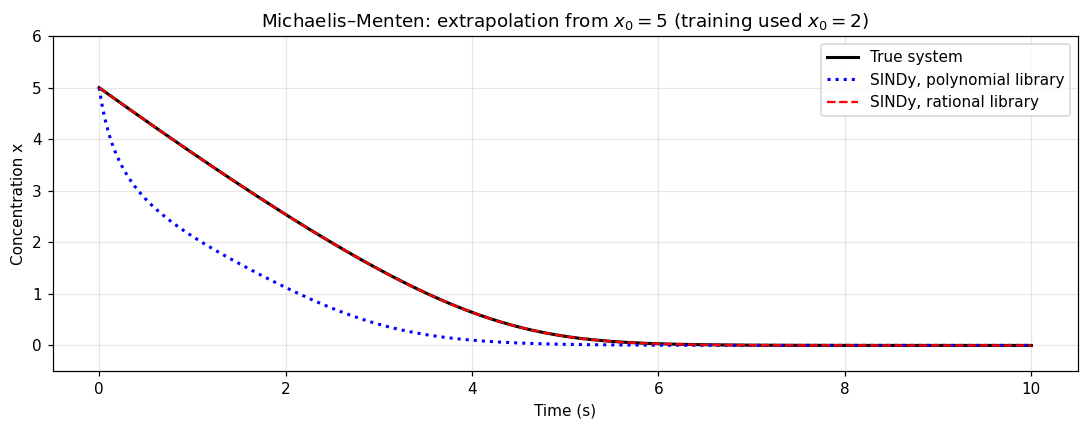

In [ ]:
t_long = np.linspace(0, 10, 1000)
x0_mm = [5.0]  # unseen, larger initial concentration
x_true = solve_ivp(michaelis_menten, (0, 10), x0_mm, t_eval=t_long, rtol=1e-10).y.T
x_poly = poly_model.simulate(x0_mm, t_long, integrator_kws={"method": "LSODA"})
x_rat = rat_model.simulate(x0_mm, t_long)

plt.figure(figsize=(10, 4))
plt.plot(t_long, x_true, "k-", lw=2, label="True system")
plt.plot(t_long[: len(x_poly)], x_poly, "b:", lw=2, label="SINDy, polynomial library")
plt.plot(t_long, x_rat, "r--", lw=1.5, label="SINDy, rational library")
plt.ylim(-0.5, 6)
plt.xlabel("Time (s)"); plt.ylabel("Concentration x")
plt.title(r"Michaelis–Menten: extrapolation from $x_0 = 5$ (training used $x_0 = 2$)")
plt.legend()
plt.tight_layout()
plt.show()

The polynomial model is a three-term curve fit with no physical meaning, and it fails when extrapolated beyond the concentrations it saw in training. With a rational term in the library, SINDy selects **one** term with the exact coefficient $V_{\max} = 1.5$, and the model extrapolates correctly.

The rational term $x/(K_m + x)$ was built with the true $K_m$. When $K_m$ is unknown, one can scan over candidate values or use the implicit formulation (SINDy-PI).

## Summary

| System | Library | Result |
|---|---|---|
| Lorenz (chaotic) | Polynomials, degree ≤ 2 | 7 of 30 terms selected, all within 0.15 % of the true values. Correct attractor geometry. |
| Lorenz, 1 % noise | Same, with smoothed differentiation | Still exactly 7 terms. Maximum coefficient error drops from 4.6 % to 1.3 % with smoothing. |
| Pendulum (undamped / damped) | Linear + {sin, cos} | Exact $\sin\theta$ nonlinearity and damping recovered. Valid at θ₀ = 90°. |
| Michaelis–Menten | Polynomial vs rational | Polynomial: a non-physical fit that fails to extrapolate. Rational: one exact term. |

**Takeaways:** SINDy recovers interpretable, physically meaningful models from data, provided that (i) the derivatives are estimated carefully, especially with noisy data, and (ii) the candidate library contains the right kinds of functions. Domain knowledge enters through the choice of library.